Dataset Created Successfully!
   Size_sqft  Bedrooms  Age_of_house  Distance_from_city  Location_rating  \
0   2.056544  0.606851      0.482688           -1.130888         0.420094   
1  -0.799192 -0.645964     -0.182896           -0.482744         1.374876   
2   1.076007 -0.796026     -0.751969            0.021312        -0.319054   
3  -0.103255 -0.828497      1.489863           -1.643189        -1.600904   
4  -2.063403  0.503252     -0.645572           -0.317350        -1.661083   

       Price  
0  66.595254  
1 -61.659436  
2 -49.947499  
3 -79.939739  
4 -80.651266  


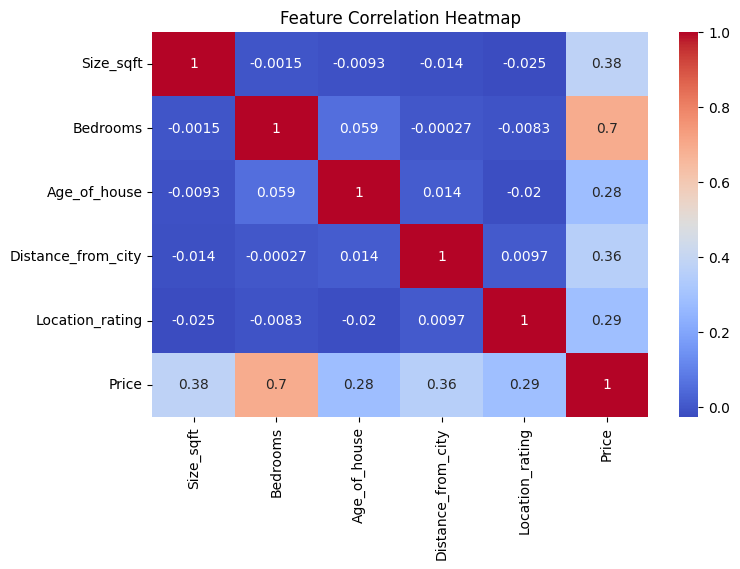


🔹 Linear Regression Results
MAE: 17.070207775943924
MSE: 443.62438733858727
R2 Score: 0.894195002713362

🔹 Random Forest Results
MAE: 22.182798085517444
MSE: 804.2791068641516
R2 Score: 0.8081783798452162


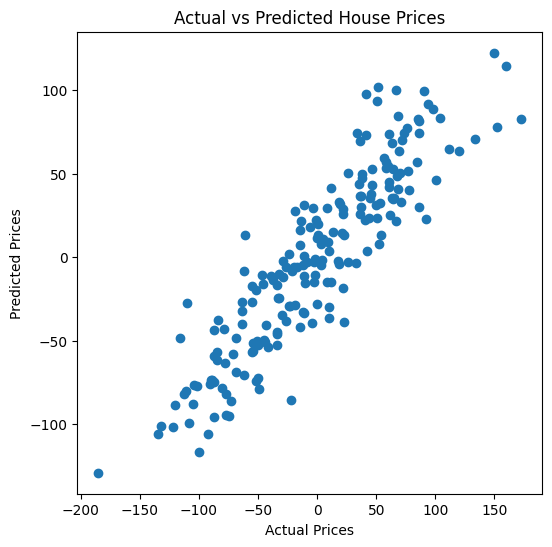


🏠 Predicted House Price: 162.05931208620694


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# =========================================================
# HOUSE PRICE PREDICTION (NO INTERNET DATASET VERSION)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1️⃣ Create Synthetic Housing Dataset
X, y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=20,
    random_state=42
)

df = pd.DataFrame(X, columns=[
    "Size_sqft",
    "Bedrooms",
    "Age_of_house",
    "Distance_from_city",
    "Location_rating"
])
df["Price"] = y

print("Dataset Created Successfully!")
print(df.head())

# 2️⃣ Visualization
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# 3️⃣ Split Data
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4️⃣ Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("\n🔹 Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

# 5️⃣ Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\n🔹 Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

# 6️⃣ Graph
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# 7️⃣ Custom Prediction
sample_house = [[1500, 3, 10, 5, 8]]
sample_house = scaler.transform(sample_house)
predicted_price = rf_model.predict(sample_house)

print("\n🏠 Predicted House Price:", predicted_price[0])